<a href="https://colab.research.google.com/github/LucasDSF7/Data-Analysis-Puc-Rio/blob/master/ia_jobs_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Davi Santos Farias

**Matrícula:** 4052025002520

**Dataset:** [IA Jobs Market 2025 and 2026](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)

# Descrição do Problema

Esse dataset possui um conjunto de dados de com 1500 anúncios de emprego nas áreas de IA e Machine Learning referentes ao período de 2025 e 2026, abrangendo 25 funções em 14 países. O dataset inclui salários, competências em alta, tendências de trabalho remoto e análises por tamanho de empresa. O objetivo principal é prever o salário baseado nas características fornecidas.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Ao longo do tempo existe uma tendência para uma maior proporção de anúncios de cargos de LLM?**

2. **Número de anos de experiência exigido corresponde com o nível de experiência exigida (Entry, Mid, Senior, Lead)?**

3. **A habilidade mais requisitada nos anúncios é Python?**

4. **Existem situações em que o salário anual de anúncio Entry Level é maior do que níveis Senior ou Lead?**

5. **Existem países do globo em que anúncios voltados a LLM são mais comuns?**

## Tipo de Problema

Este é um problema de **regressão supervisionada**. Dado um conjunto de dados, o objetivo é prever qual o salário do anúncio.

## Seleção de Dados

O dataset IA Jobs Market é um conjunto de dados disponível no Kaggle com licença CC0: Public Domain com expectativa de atualização de dados "Annually". Houve uma etapa de seleção de dados externa (ia_jobs_citys_location.csv) para alimentar o dataset proposto com latitude e longitude de referência para cada cidade, foi utilizado o Google Maps para coleta de dados de localização.

O dataset IA Jobs foi compilado a partir de fontes de dados públicos sobre salários (2025 - 2026):

Ravio Global Salary Benchmark 2026

Robert Half Technology Salary Guide 2026

Motion Recruitment AI/ML Salary Report 2025

LinkedIn Workforce Insights 2025-2026

Glassdoor AI Role Salary Data 2025

A condição para selecionar os dados foram:
- Disponibilidade pública;
- Pelo menos 20 atributos no dataset, numéricos e categóricos;
- Dados reais que pudessem fornecer insights reais.

## Atributos do Dataset

O dataset IA Jobs Market contém 1.500 registros e possui 25 atributos:

- ***job_id*** (Identificador único para cada anúncio)
- ***job_title*** (Nome da função de IA ou ML (25 funções))
- ***job_category*** (Nome da categoria que a função se encaixa (AI Engineering, Data Science, MLOps...))
- ***experience_level*** (Experiência exigida)
- ***years_of_experience*** (Número mínimo de anos de experiência exigido)
- ***education_required*** (Educação mínima (Bachelor's / Master's / PhD / Bootcamp))
- ***annual_salary_usd*** (Salário anual em dólares)
- ***salary_min_usd*** (Valor mínimo da faixa salarial anunciada para esta função)
- ***salary_max_usd*** (Valor máximo da faixa salarial anunciada para esta função)
- ***city*** (Cidade onde a vaga está localizada)
- ***country*** (País onde a vaga está localizada)
- ***remote_work*** (On-site / Hybrid / Fully Remote)
- ***company_size*** (Tamanho da empresa: (Startup / SME / Mid-size / Enterprise / Big Tech))
- ***industry*** (Setor da indústria da vaga)
- ***required_skills*** (Habilidades exigidas para a vaga separada por "|")
- ***ia_salary_premium_pct*** (Porcentagem de prêmio salarial em comparação a uma função equivalente fora da área de IA)
- ***demand_score*** (Métrica que varia de 0 a 100 baseada no volume de contratações para a função anunciada)
- ***demand_growth*** (Porcentagem anual de crescimento na demanda por vaga)
- ***benefits_score_10*** (Qualidade dos benefícios oferecidos (0 a 10))
- ***posting_year*** (Ano em que o anúncio foi publicado)
- ***posting_month*** (Mês em que o anúncio foi publicado)
- ***is_senior*** (Se a vaga é para Sênior/Lead ou não)
- ***is_remote_friendly*** (1 se é híbrido ou completamente à distância. 0 se é em escritório)
- ***is_llm_role*** (Se é uma função que envolve LLMs)
- ***salary_tier*** (Salary bracket: Entry / Mid / Upper-Mid / Senior / Elite)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset IA Jobs Market.

In [1]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/LucasDSF7/Data-Analysis-Puc-Rio/refs/heads/master/mvp/data/ai_jobs_market_2025_2026.csv')
# city_locations é um dataframe auxiliar com a latitude e longitude das cidades do dataset principal.
city_locations = pd.read_csv('https://raw.githubusercontent.com/LucasDSF7/Data-Analysis-Puc-Rio/refs/heads/master/mvp/data/ai_jobs_citys_location.csv')
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset IA Jobs Market, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset IA Jobs Market possui 1.500 instâncias (observações) e 25 atributos. As caractéristicas variam entre o tipo numérico e categórica, com o atributo alvo sendo númerico contínuo, explicando o motivo do problema ser do tipo regressão supervisionada.

É possível observar que esse dataset não possui missings.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

## Tratamento de Valores Nulos

Como mencionado, o dataset não possui missings. Podemos ter uma visualização utilizando o método isna() do pandas, somando todos os missings.

In [4]:
df.isna().sum().sum()

np.int64(0)

## Limpeza de Dados Redundantes

Alguns atributos são claramente derivados de outros atributos que agregam valor. Por exemplo:

- salary_min_usd e salary_max_usd são derivados da coluna annual_salary_usd.

- is_senior é uma coluna binária informando se experience_level é do tipo senior ou lead.

- is_remote_friendly é derivado do atributo remote_work.

- salary_tier é uma categorização de annual_salary_usd.

O atributo job_id também será descartado por se tratar de um indexador do anúncio, sem benefício para o modelo.

Além de descartar os atributos citados, também serão descartadas linhas duplicadas, se existirem.

Antes de tudo, como medida de boas práticas, será criado uma cópia do dataset originial, utilizando o método copy com parâmetro deep=True do Dataframe Pandas.

In [5]:
df_copy = df.copy(deep=True)

In [6]:
df_copy.drop(columns=['salary_min_usd', 'salary_max_usd', 'is_senior', 'is_remote_friendly', 'salary_tier', 'job_id'], inplace=True)
df_copy.drop_duplicates(inplace=True)

## Agregação de colunas

No dataset existem duas colunas (posting_month, posting_year) que podem ser unificadas em uma única, do tipo datetime que vou chamar posting_date.

As colunas (posting_month, posting_year) serão descartadas após a operação.

In [7]:
df_copy['posting_date'] = df_copy.apply(lambda x: datetime.strptime(f"{x['posting_month']}/{x['posting_year']}", "%m/%Y"), axis=1)
df_copy[['posting_month', 'posting_year', 'posting_date']].head()

,posting_month,posting_year,posting_date
0,3,2026,2026-03-01
1,1,2026,2026-01-01
2,1,2026,2026-01-01
3,3,2026,2026-03-01
4,1,2026,2026-01-01


In [8]:
df_copy.drop(columns=['posting_month', 'posting_year'], inplace=True)

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [9]:
@dataclass
class HistogramConfig:
    sr: pd.Series
    bins: list[int]
    title: str
    x_label: str = ''
    y_label: str = 'Número de registros'


def numeric_feature_hist_box_plots(config: HistogramConfig) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].hist(config.sr, bins=config.bins)
    ax[0].set_xticks(config.bins)
    ax[0].set_title(config.title)
    ax[0].set_ylabel(config.y_label)
    ax[0].set_xlabel(config.x_label)

    ax[1].boxplot(config.sr)
    ax[1].set_title(config.title)

df_copy.describe()

,years_of_experience,annual_salary_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,posting_date
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500
mean,6.216000,194892.000000,10.858200,87.523333,31.116333,7.897333,0.218000,2025-10-30 20:31:40.800000256
min,1.000000,90000.000000,3.000000,68.000000,5.000000,6.000000,0.000000,2025-01-01 00:00:00
25%,4.000000,144750.000000,8.200000,82.000000,15.375000,6.900000,0.000000,2025-08-01 00:00:00
50%,6.000000,180000.000000,10.500000,89.000000,23.400000,7.900000,0.000000,2026-01-01 00:00:00
75%,8.000000,236250.000000,14.200000,95.000000,42.700000,8.900000,0.000000,2026-02-01 00:00:00
max,15.000000,384000.000000,18.000000,98.000000,87.800000,9.800000,1.000000,2026-03-01 00:00:00
std,2.675216,66506.822013,4.029742,8.026315,22.046343,1.102846,0.413025,NaN


### Years of experience

A média de anos de experiência exigida é de 6,2 anos indicando que as vagas anunciadas tendem a contratar profissionais experientes. O valor mínimo de 1 ano de experiência mostra que mesmo para cargos Entry Level, é exigido algum tipo de experiência profissional.

O Histograma mostra que a maior parte dos anúncios pede entre 6 e 8 anos de experiência e possuia uma distribuição normal.

O Boxplot mostra que existe um outlier, em que um anúncio exige 15 anos de experiência para o cargo, porém essa exigência de experiência faz sentido para algumas vagas.

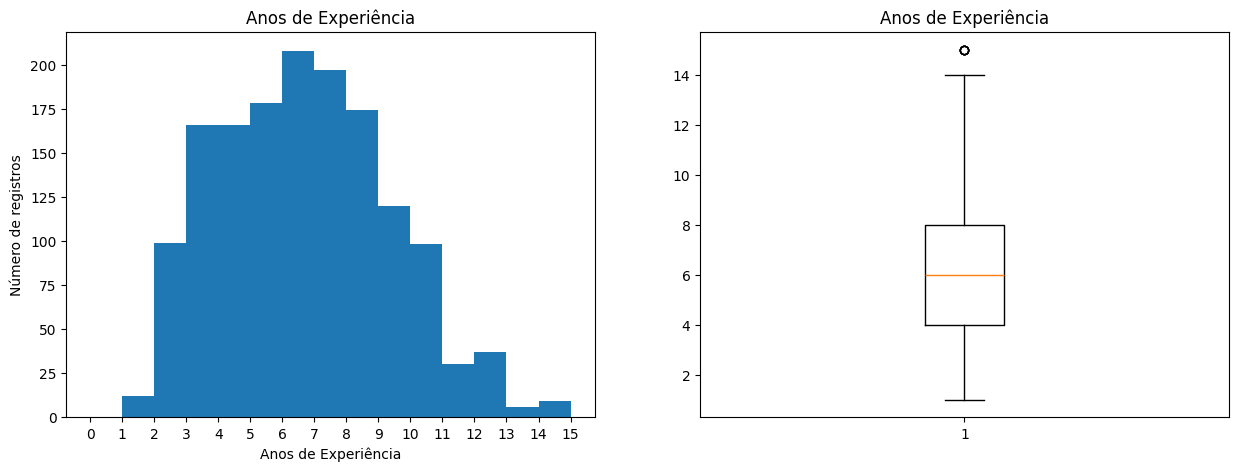

In [10]:
config = HistogramConfig(sr=df_copy['years_of_experience'], bins=list(range(0, 16)), title='Anos de Experiência', x_label='Anos de Experiência')
numeric_feature_hist_box_plots(config)

### Annual salary usd

O salário anual possui uma média de 194.892 dólares por ano, com um alto desvio padrão de 66.506 dólares. O valor mínimo é de 90 mil dólares e o máximo de 384 mil dólares.

O histograma possui uma distribuição assimétrica à direita, mostrando que é mais raro ter salários mais altos.

O Boxplot mostra alguns salários altos como outliers, porém são valores possíveis.

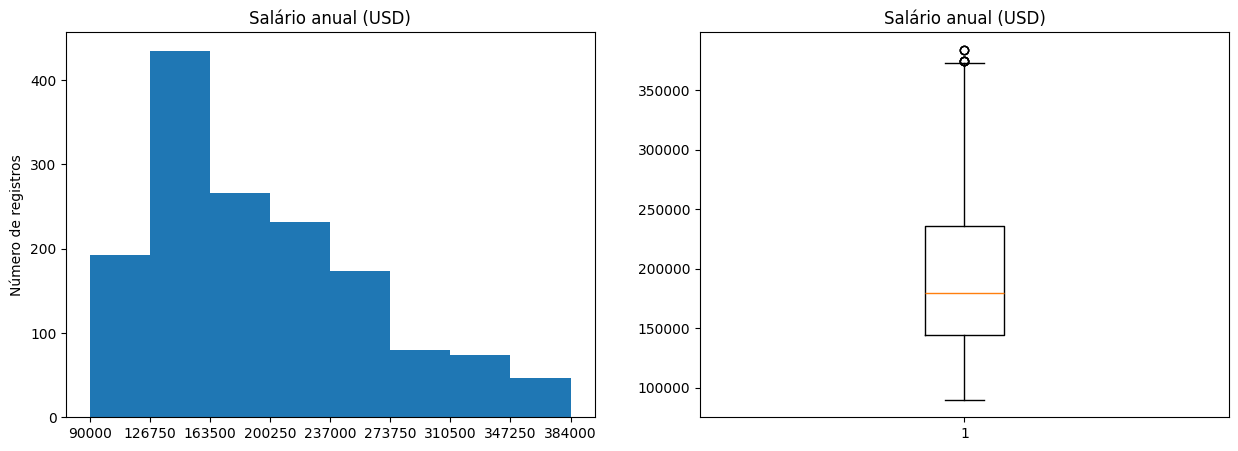

In [11]:
sr = df_copy['annual_salary_usd']
step = int((sr.max() - sr.min())) // 8
config = HistogramConfig(sr=sr, bins=list(range(90000, 384000 + step, step)), title='Salário anual (USD)', x_label='')
numeric_feature_hist_box_plots(config)

### Ai salary premium pct

A média de porcentagem de prêmio salarial é de 10,86 % com mínimo de 3 % e máximo de 18 %, indicando que a área de IA e ML paga melhor do que outras áreas semelhantes, talvez devido a uma alta na demanda por profissionais.

O histograma possui uma distribuição irregular, com a maior frequência de porcentagem de prêmio entre 8 e 10 %.

O boxplot indica que não existem outliers.

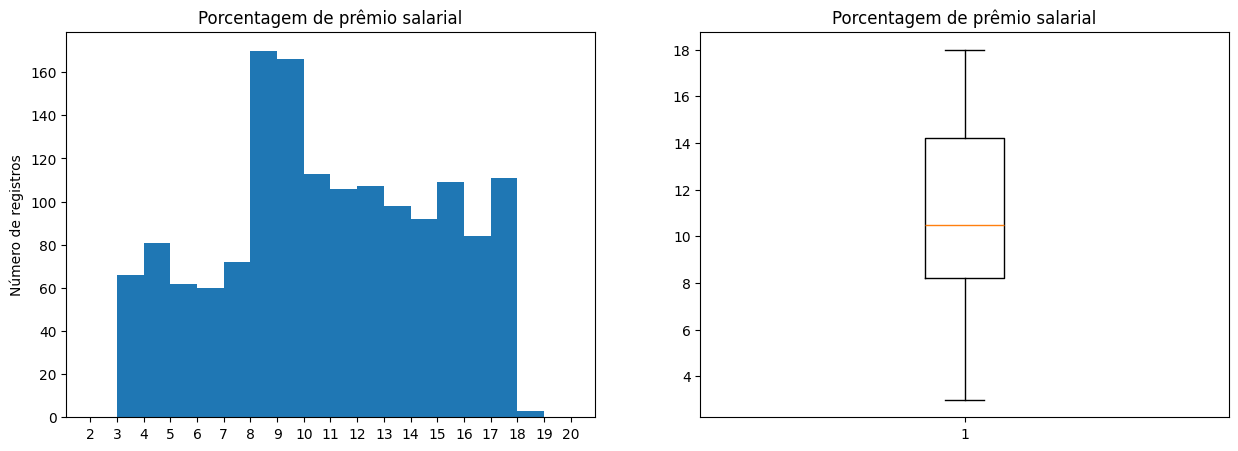

In [12]:
sr = df_copy['ai_salary_premium_pct']
config = HistogramConfig(sr=sr, bins=list(range(2, 21, 1)), title='Porcentagem de prêmio salarial')
numeric_feature_hist_box_plots(config)

### Demand score

Corroborando com o que foi aprendido com o atributo ai_salary_premium_pct, existe uma demanda alta por profissionais de IA, com média de pontuação de demanda de 87,52.

O histograma possui uma distribuição assimétrica à esquerda, com a maior frequência de pontuação entre 95 e 100.

O boxplot não indica existência de outliers.

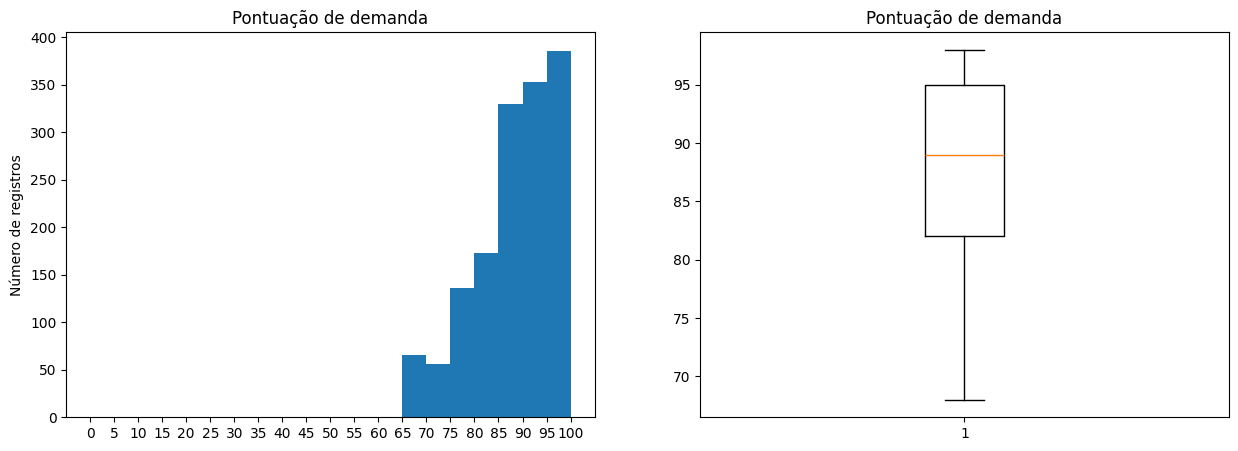

In [13]:
sr = df_copy['demand_score']
config = HistogramConfig(sr=sr, bins=list(range(0, 105, 5)), title='Pontuação de demanda')
numeric_feature_hist_box_plots(config)

### Demand growth yoy pct

Só existem dois anos de registros de anúncios nesse dataset, portanto não é possível inferir muito sobre os dados desse atributo.

O histograma possui uma distribuição assimétrica à direita, indicando que a maior parte dos cargos de IA não sofreu um aumento muito grande na demanda de um ano para outro.

O boxplot indica a existência de outliers, com valores próximos a 100 % no aumento da demanda, que pode ser explicado pelo boom gerado no mercado de IA generativa.

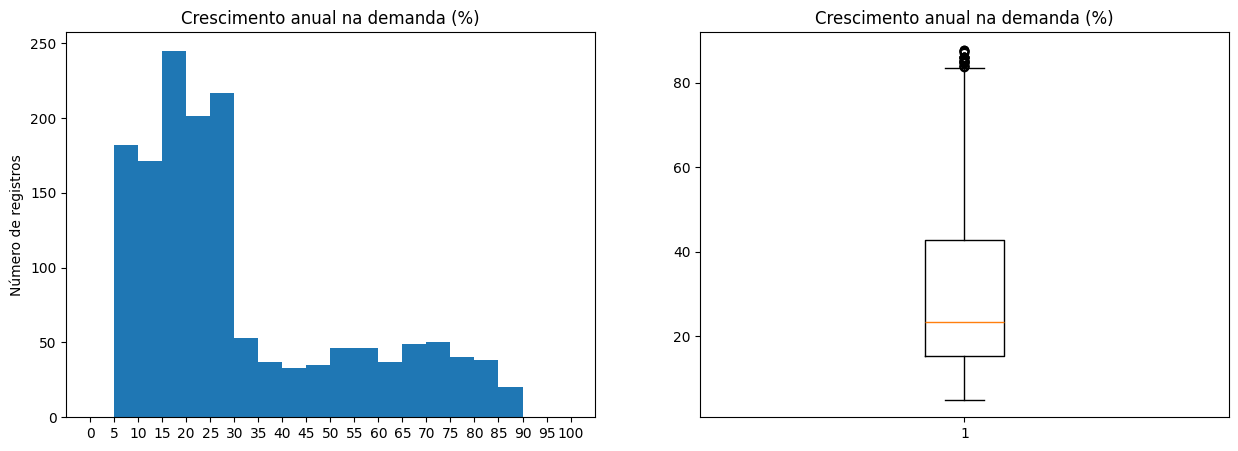

In [14]:
sr = df_copy['demand_growth_yoy_pct']
config = HistogramConfig(sr=sr, bins=list(range(0, 105, 5)), title='Crescimento anual na demanda (%)')
numeric_feature_hist_box_plots(config)

Cargos que tiverem o maior crescimento de demanda no último ano:

In [15]:
df_copy.loc[df_copy['demand_growth_yoy_pct'] >= 80].groupby('job_title').size().sort_values(ascending=False)

,0
job_title,
RAG Engineer,9
LLM Engineer,8
NLP Engineer,7
Generative AI Engineer,7
Senior ML Engineer,6
AI Engineer,6
AI Agent Developer,4
Data Scientist,4
MLOps Engineer,4


### Benefits score 10

A pontuação de benefícios possui média 7,89 com desvio padrão baixo de 1,1, indicando que os anúncios tendem a ofertar bons benefícios aos contratados.

O histograma possui uma distribuição assimétrica à esquerda, com valores de pontuação uniformemente distribuídos entre 6 e 10.

O boxplot não indica a existência de outliers.

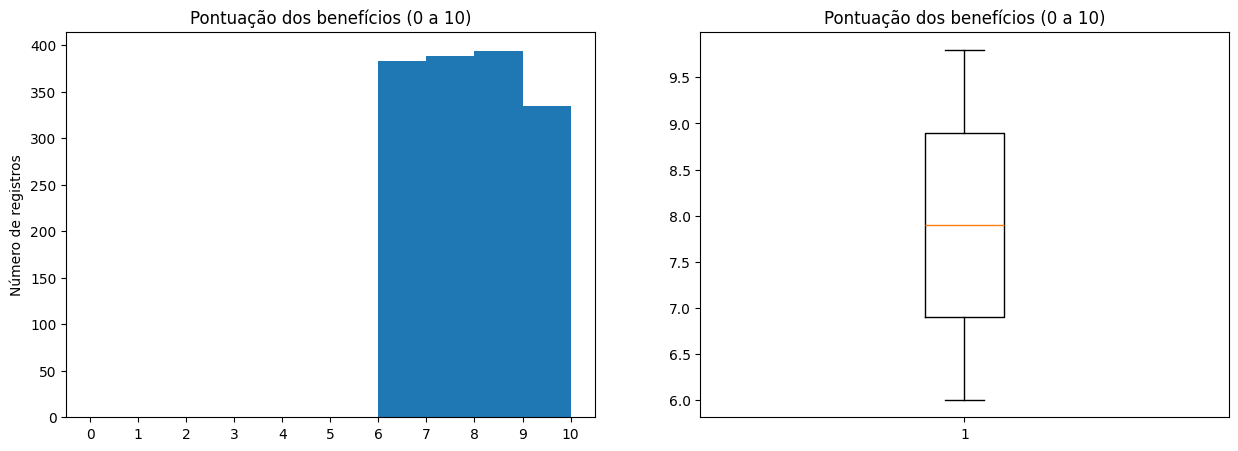

In [16]:
sr = df_copy['benefits_score_10']
config = HistogramConfig(sr=sr, bins=list(range(0, 11)), title='Pontuação dos benefícios (0 a 10)')
numeric_feature_hist_box_plots(config)

## Scatter Plot

A seguir, scatter plot entre as variáveis numéricas.

O maior ponto de interesse é a relação das variáveis com o Annual Salary USD. Visualmente, apenas a variável demand_score parece possuir uma correlação positiva com annual salary usd.

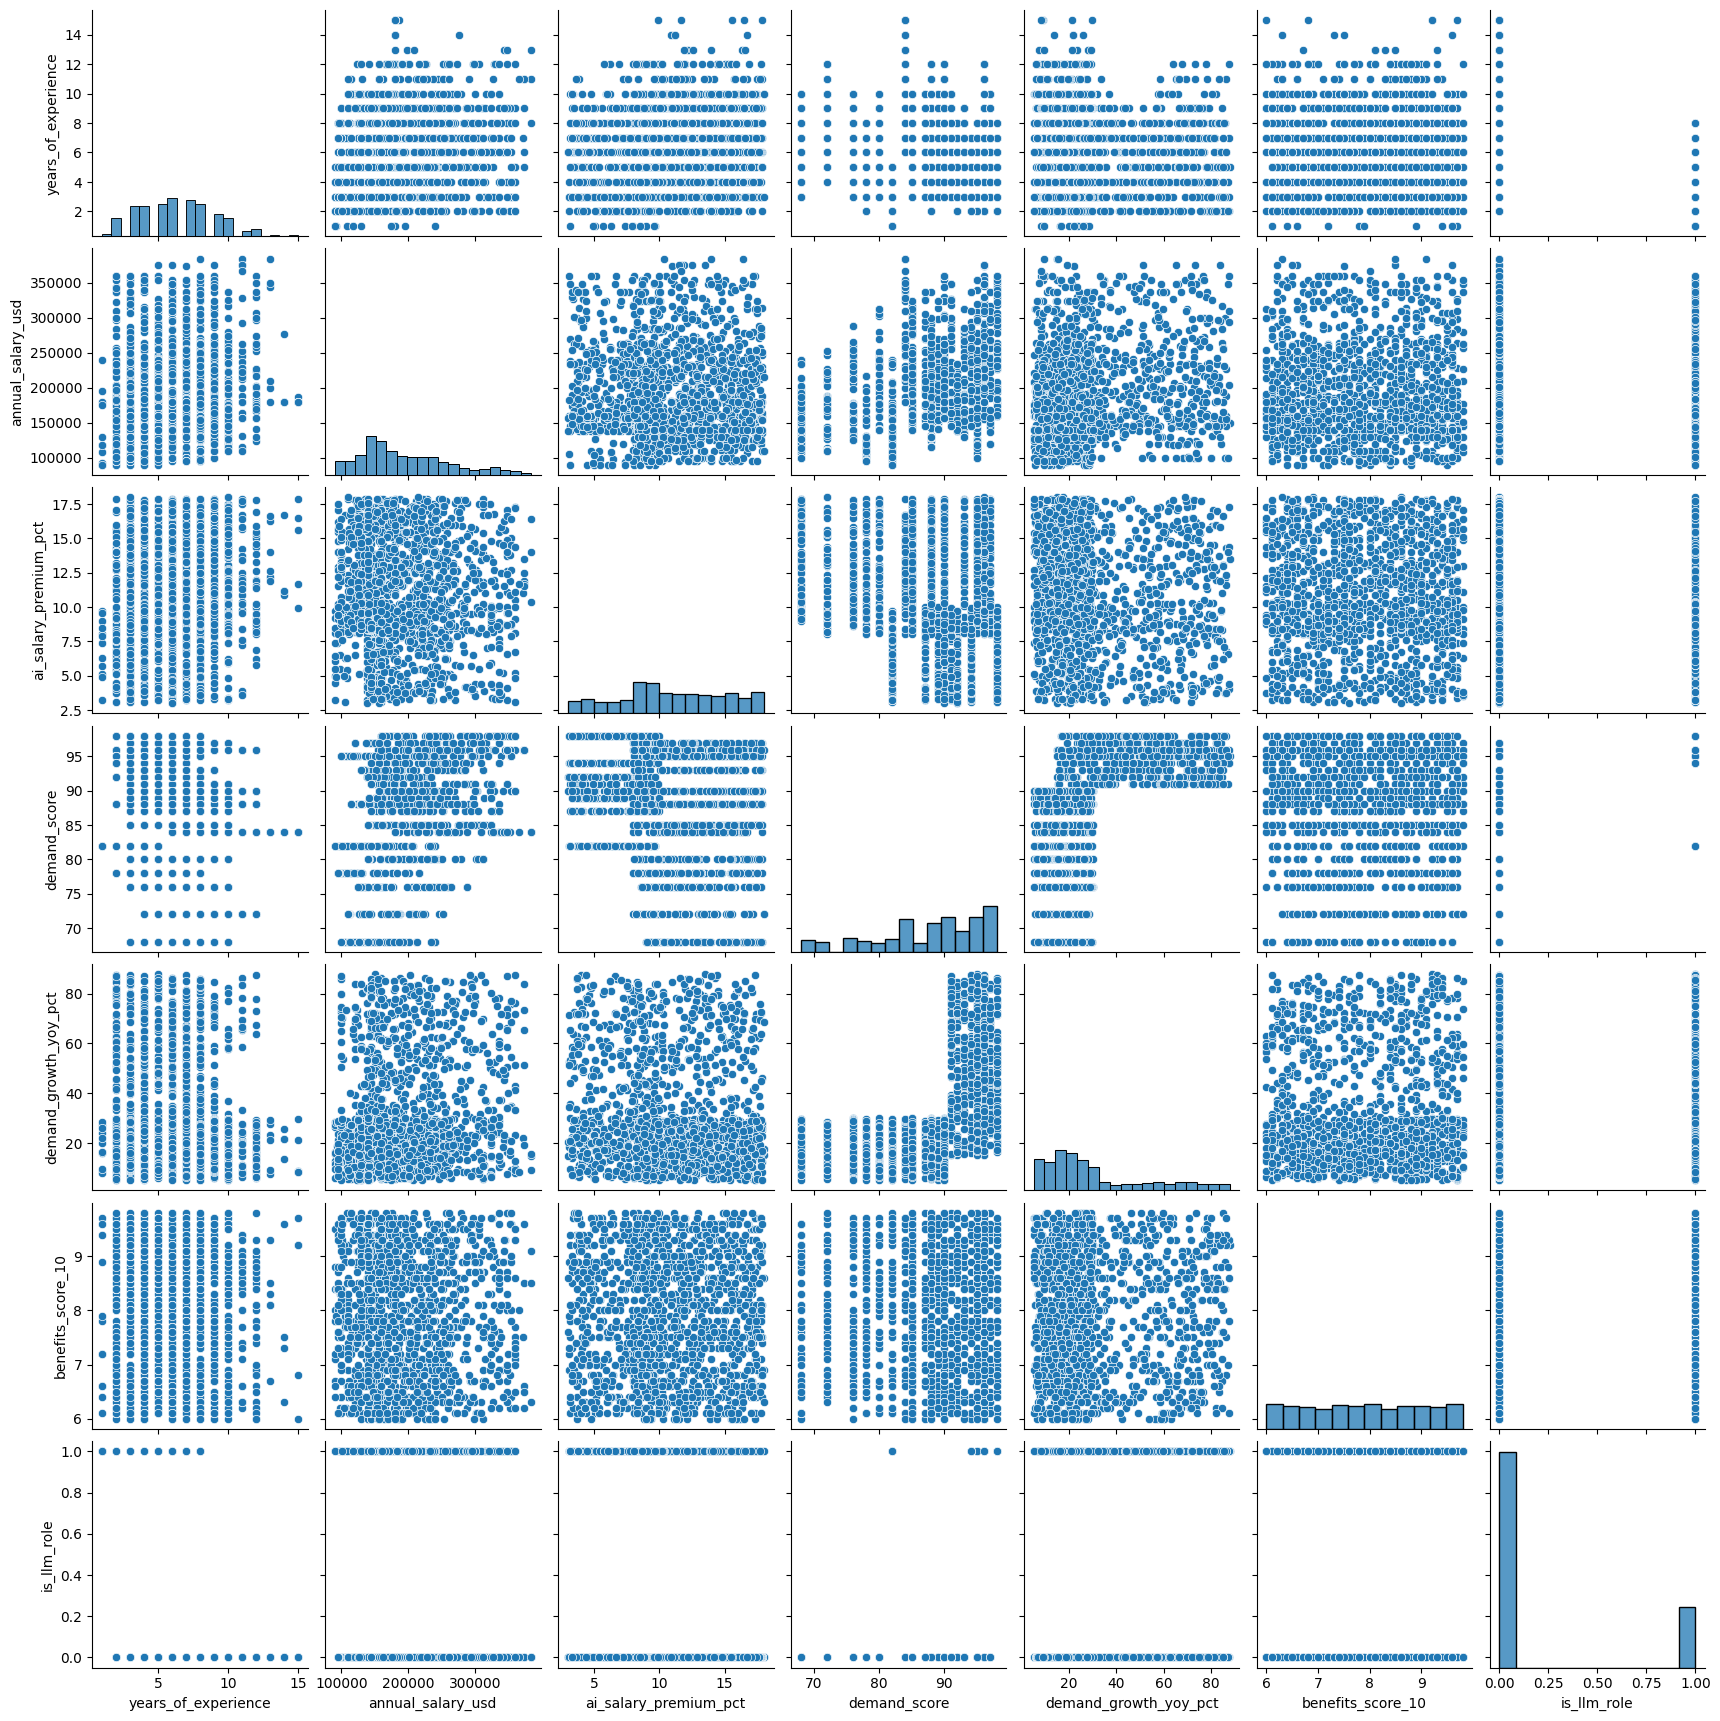

In [17]:
sns.pairplot(df_copy)

## Matrix de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Pontos de interesse:

- Annual Salary USD possui uma correlação positiva com demand_score e demand_growth_yoy_pct. Possivelmente esse aumento de demanda para certos cargos faz com que o salário aumente.
- Years of Experience possui uma correlação negativa com is_llm_role. Pode-se interpretar que como é um mercado de IA novo, os anúncios exigem menos anos de experiência.
- Demand_Score possui uma correlação positiva com is_llm_role. O boom no mercado de IA voltado a IA generativa deve ter aumentado a demanda por esse cargo.

<Axes: >

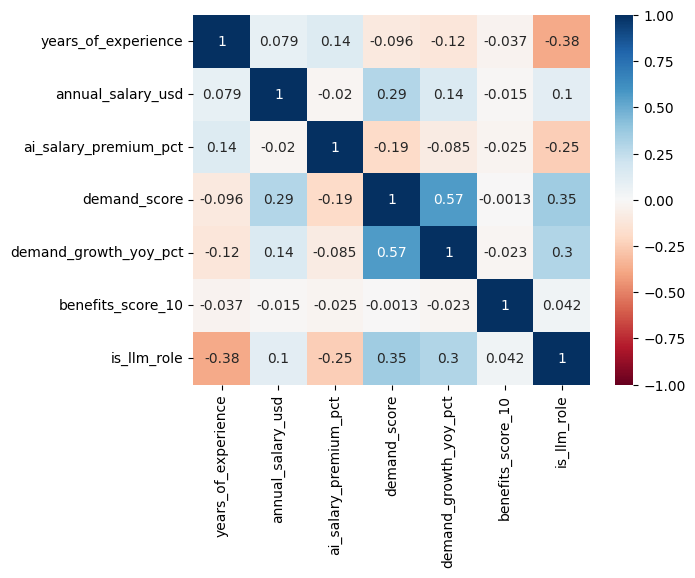

In [18]:
sns.heatmap(data=df_copy.corr(numeric_only=True), vmin=- 1, vmax=1, cmap='RdBu', annot=True)

## Análise dos atributos categóricos

Vamos analisar o comportamento das variáveis categóricas.

Quando existirem poucos valores distintos no atributo categórico, será utilizado um gráfico de pizza com um density plot com hue para termos uma visualização de como o atributo se relaciona com Annual Salary USD.

Para atributos categóricos com muitos valores distintos, será utilizado um gráfico de barras com o valor médio de Annual Salary USD.

In [19]:
def categoric_feature_bar_plot(df: pd.DataFrame, label: str) -> None:
    '''
    Cria uma gráfico de barras horizontal com valores médios de Annual Salary USD.
    '''
    gb = df.groupby(label).mean(numeric_only=True)['annual_salary_usd']
    gb = gb.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.barh(y=gb.index, width=gb.values)
    ax.set_xlabel('Annual Salary Mean (USD)')
    ax.set_ylabel(label.replace('_', ' ').capitalize())
    ax.bar_label(ax.containers[0], fmt="%.0f")

In [20]:
def func(pct, allvals):
    '''
    Copiado de: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html
    '''
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{absolute:d}\n{pct:.1f}%"


def categoric_feature_pie_density_plot(df: pd.DataFrame, label: str) -> None:
    '''
    Cria um gráfico de pizza seguindo o código em: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html.
     E um gráfico de densidade usando seaborn com hue=feature.
    '''
    cmap = plt.get_cmap('tab10', 10)
    sr = df[label]
    group_by = sr.value_counts()
    data, labels = group_by.values.tolist(), group_by.index.to_list()
    color_map = {label: cmap(i) for i, label in enumerate(labels)}
    color_order = [color_map[label] for label in labels]

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    wedges, texts, autotexts = ax[0].pie(data, autopct=lambda pct: func(pct, data), textprops=dict(color="w"), colors=color_order)
    ax[0].legend(wedges, labels,
          title=label.replace('_', ' '),
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
    plt.setp(autotexts, size=8, weight="bold")
    sns.kdeplot(df, x='annual_salary_usd', hue=label, ax=ax[1], palette=color_map)
    ax[0].set_title(f'{label.replace("_", " ")} distribution')
    fig.show()

### Job Title

No datasete, 25 cargos distintos foram anunciados. Olhando o gráfico de barras horizontais com valores médios de salários anuais, é possível ter uma noção de como é a distribuição salarial por cargo, com AI Solutions Architect possuindo a maior média salarial.

Número de cargos anunciados: 25


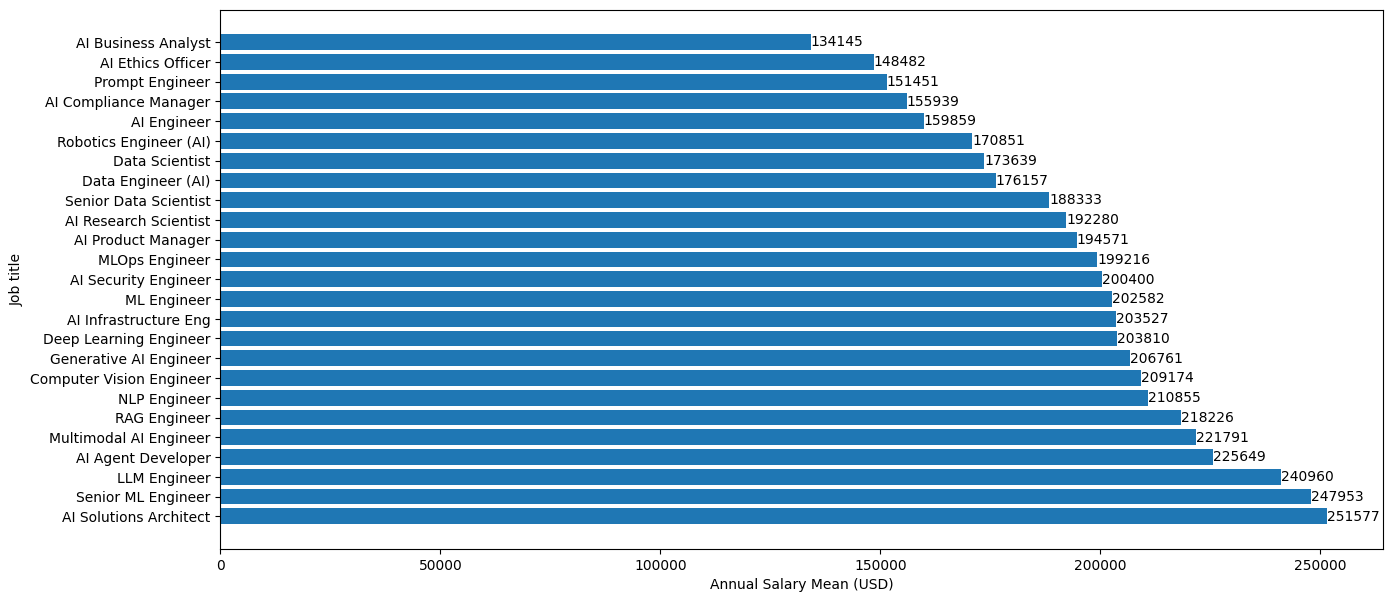

In [21]:
print(f'Número de cargos anunciados: {df_copy["job_title"].unique().size}')
categoric_feature_bar_plot(df_copy, 'job_title')

### Job Category

Das áreas anunciadas, a que possui a maior média salarial é a Architecture, com Business e Governance possuindo as menores médias salariais

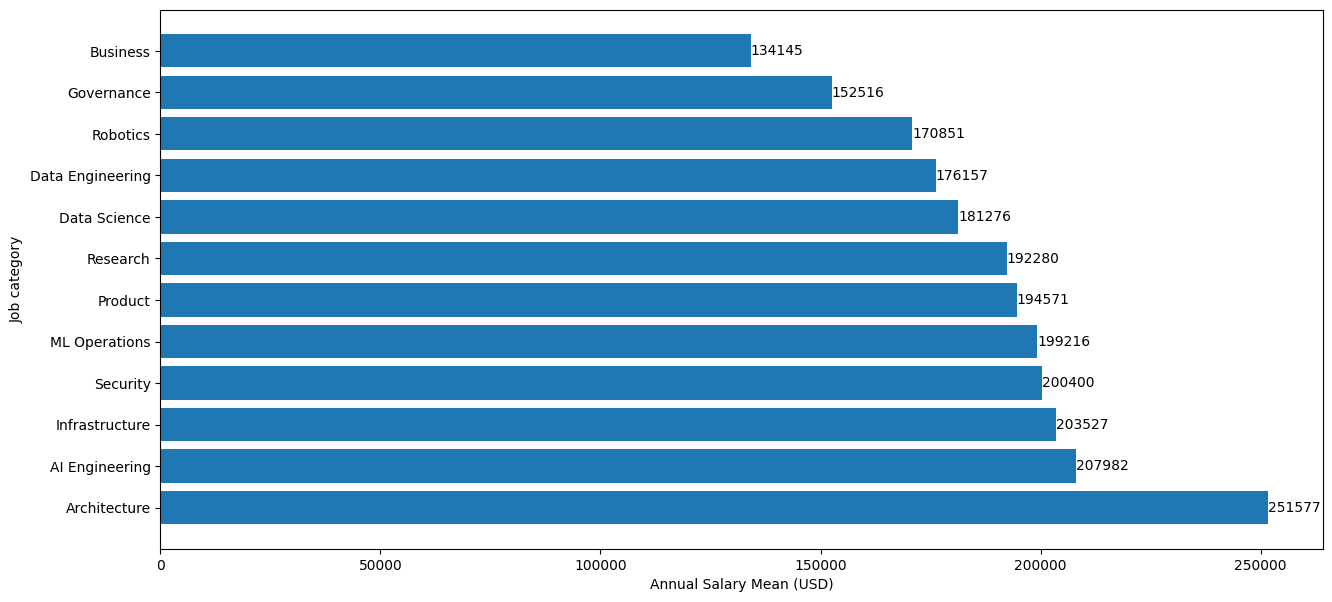

In [22]:
categoric_feature_bar_plot(df_copy, 'job_category')

### Experience Level

O gráfico de densidade mostra que os maiores salários em ordem são para: Lead > Senior > Mid > Entry, conforme esperado. Porém, é interessante notar que existem anúncios Entry Level ofertando salários maiores que nível Lead, isso pode estar atrelado a outros fatores como cidade do anúncio, anos de experiência, cargo do anúncio e etc.

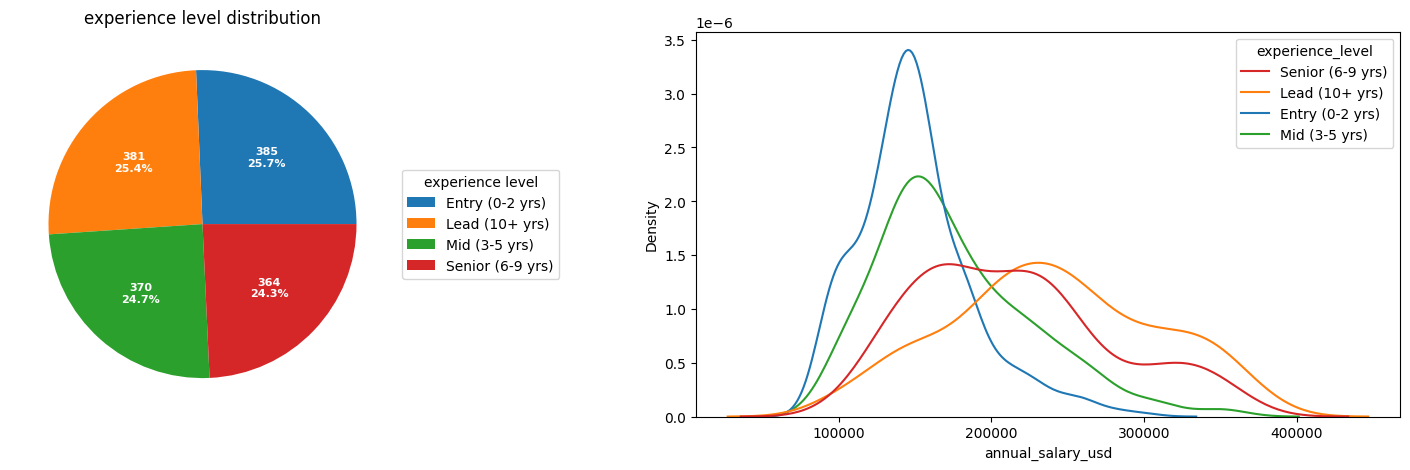

In [23]:
categoric_feature_pie_density_plot(df_copy, 'experience_level')

### Education Required

Os maiores salários por nível de educação segue uma ordem esperada: PhD > Master's > Bachelor's > Self-taught > Associate's, com exceção de talvez uma inversão de ordem entre Self-taught e Associate.

É possível notar, como também ocorreu com Experience Level, que existem anúncios sem requisitos de nível de formação (Self-taught) com salários superiores ao nível PhD, indicando que cargos de programação possuem mais flexibilidade no processo de contratação, dando prioridade à capacidade técnica do que a formação do candidato.

education_required
PhD                     213252.142857
Master's                205805.696203
Bachelor's              192321.543408
Bootcamp/Self-taught    187002.020202
Associate's             176490.540541
Name: annual_salary_usd, dtype: float64


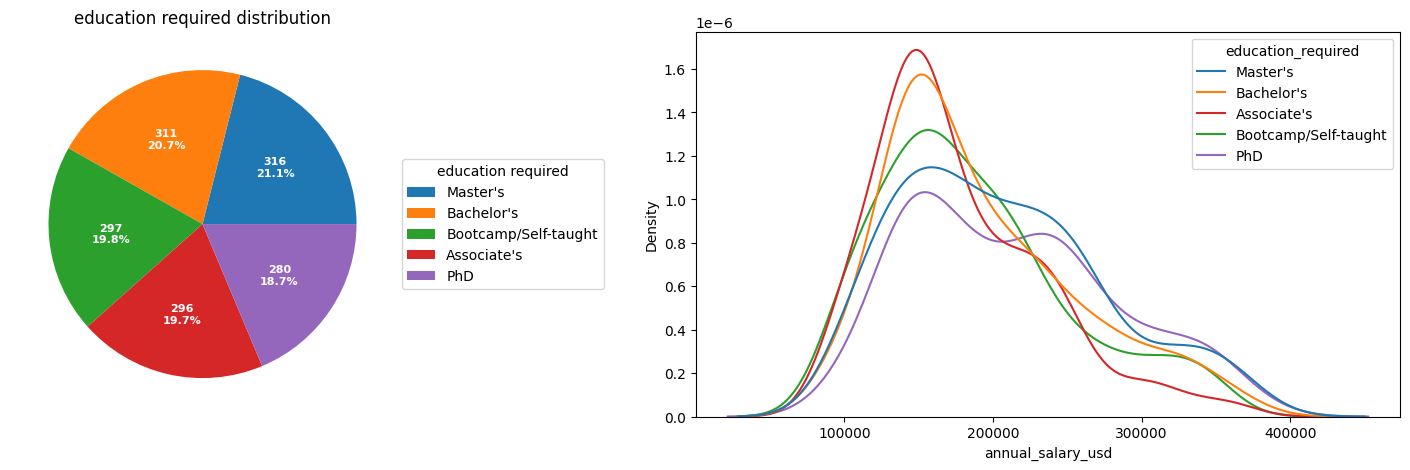

In [24]:
categoric_feature_pie_density_plot(df_copy, 'education_required')
print(df_copy.groupby('education_required').mean(numeric_only=True)['annual_salary_usd'].sort_values(ascending=False))

### Remote Work

O gráfico de pizza mostra que a maior parte dos anúncios são para configurações híbridas de rotina de trabalho, seguido de totalmente remoto e com apenas 24,6 % dos anúncios sendo totalmente presenciais.

A distribuição de salários não aparenta ter uma correlação muito forte com o modelo de trabalho anunciado.

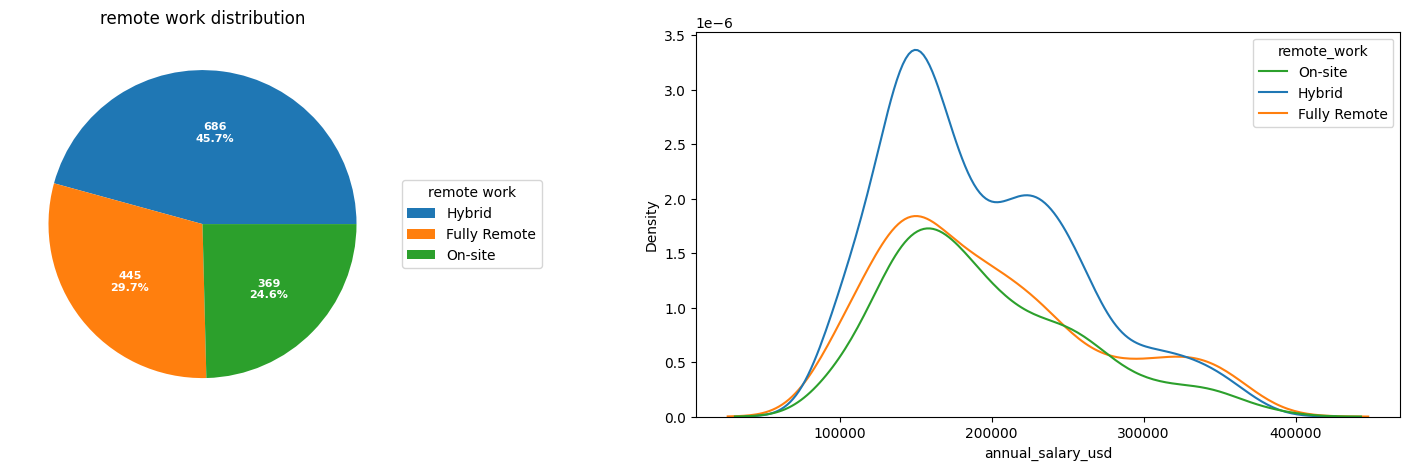

In [25]:
categoric_feature_pie_density_plot(df_copy, 'remote_work')

### Company Size

Os maiores salários por tamanho de empresa segue a ordem esperada: Big Tech > Enterprise > Mid-size > SME > Startup. Inclusive, a curva de salários de Big Techs é a única que possui uma distribuição normal, com as outras possuindo uma distribuição assimétrica à direita, significando que a maior parte dos salários ofertados são menores.

Porém, da mesma forma que nos atributos categóricos anteriores, é possível encontrar registros de anúncios de empresas Startup com salários superiores aos de empresas FAANG+.

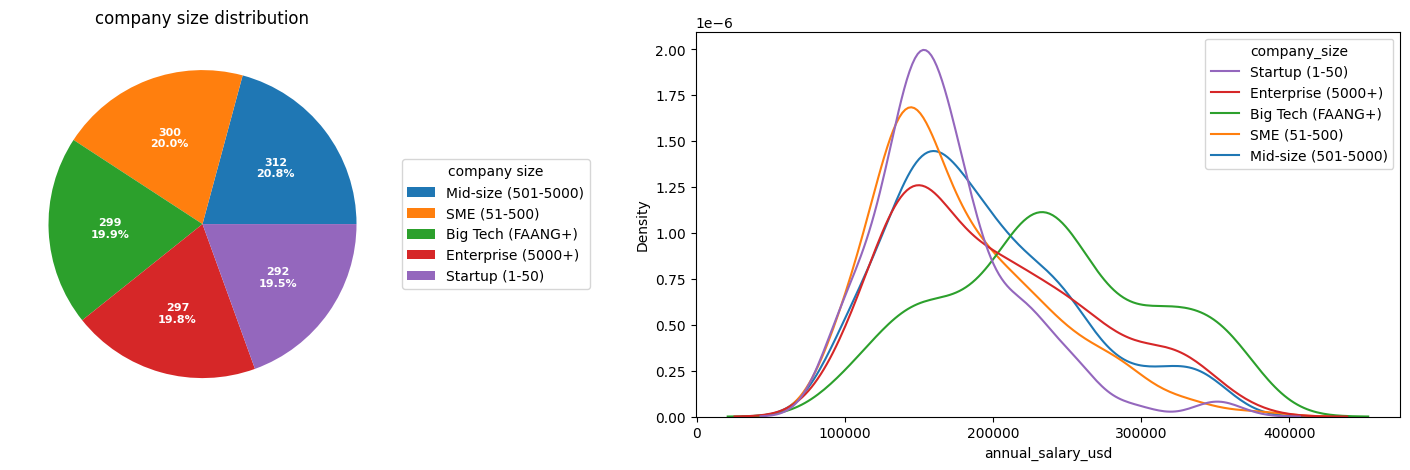

In [26]:
categoric_feature_pie_density_plot(df_copy, 'company_size')

### Industry

Os anúncios estão divididos entre 12 indústrias diferentes, com salários médio próximos. Destaque para o setor Automotivo, que desponta com uma média salarial maior que as outras indústrias.

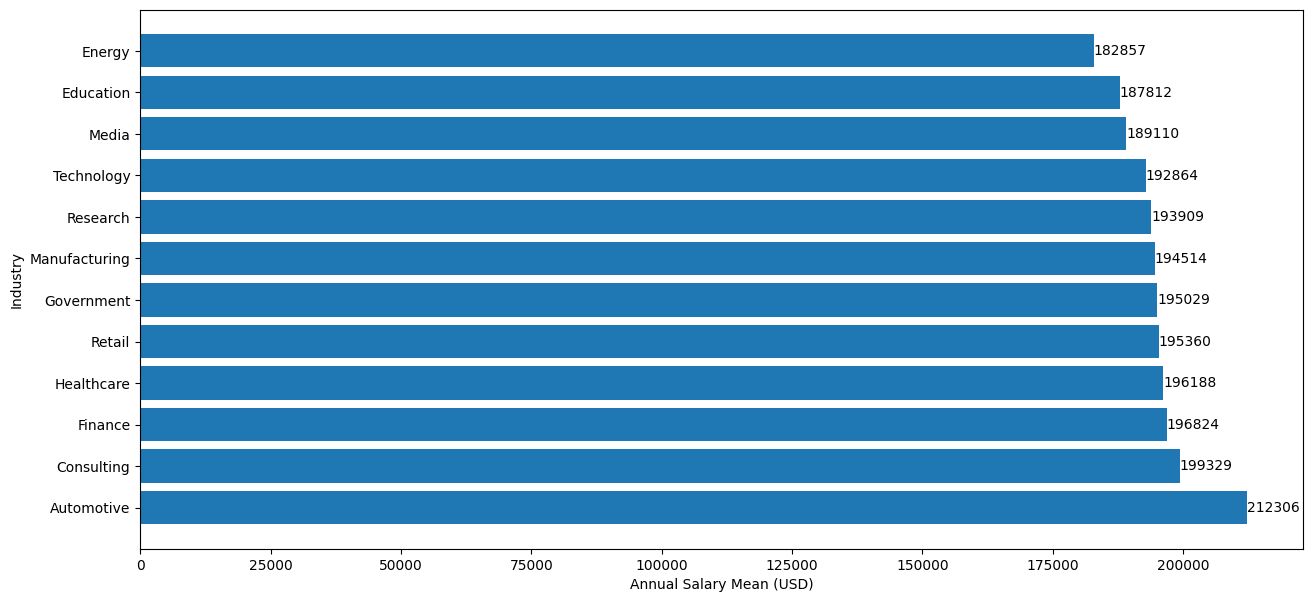

In [27]:
categoric_feature_bar_plot(df_copy, 'industry')

### City and Country

No mapa de bolha com o salário médio por cidade/país e gráfico de barras por país, é possível observar que os maiores salários são dos Estados Unidos e anúncios de vagas remotas (global), com os menores salários na China e Índia.

In [28]:
def get_cmap(value: int) -> str:
    if value > 200000:
        return 'USD > $200.000'
    elif value < 150000:
        return 'USD < $150.000'
    return '$150.000 < USD < $200.000'

In [29]:
df_map = df_copy.copy(deep=True)
df_map['city_country'] = df_copy.apply(lambda x: x['city'] + ' ' + x['country'], axis=1)
df_map = df_map.groupby('city_country').mean(numeric_only=True)['annual_salary_usd'].reset_index()
city_mapping = city_locations.set_index('city_country').to_dict()
df_map['latitude'] = df_map['city_country'].map(city_mapping['latitude'])
df_map['longitude'] = df_map['city_country'].map(city_mapping['longitude'])
df_map['size'] = df_map.apply(lambda x: x['annual_salary_usd'], axis=1)
df_map['Mean Salary USD'] = df_map['annual_salary_usd'].apply(get_cmap)
mapa = px.scatter_map(
    data_frame=df_map,
    lat=df_map['latitude'],
    lon=df_map['longitude'],
    map_style='dark',
    height=1000,
    width=1500,
    color=df_map['Mean Salary USD'],
    zoom=1.2,
    size='size',
    size_max=50,
    hover_data={'size': False, 'latitude': False, 'longitude': False, 'city_country': True, 'annual_salary_usd': True, 'Mean Salary USD': False},
    opacity=0.75
)
display(mapa)


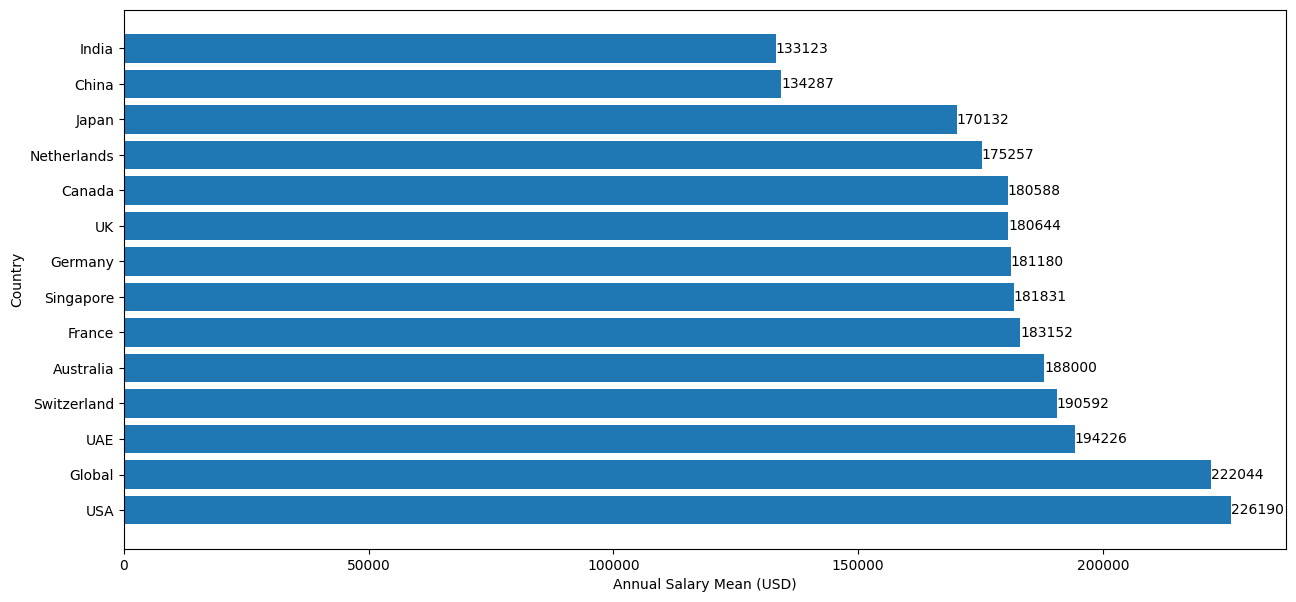

In [30]:
categoric_feature_bar_plot(df_copy, "country")

## Posting Date

No gráfico de linha com o salário médio anual em determinado mês/ano, não é possível avaliar se existe uma tendência para aumento ou diminuição no salário médio anual ofertado nos anúncios.

Provavelmente, a flutação salarial se deve mais ao fato de que existem diferentes tipos de ofertas de vagas, o que contribui para a flutuação apresentada.

Text(0.5, 1.0, 'Salário médio USD (2015 - 2016)')

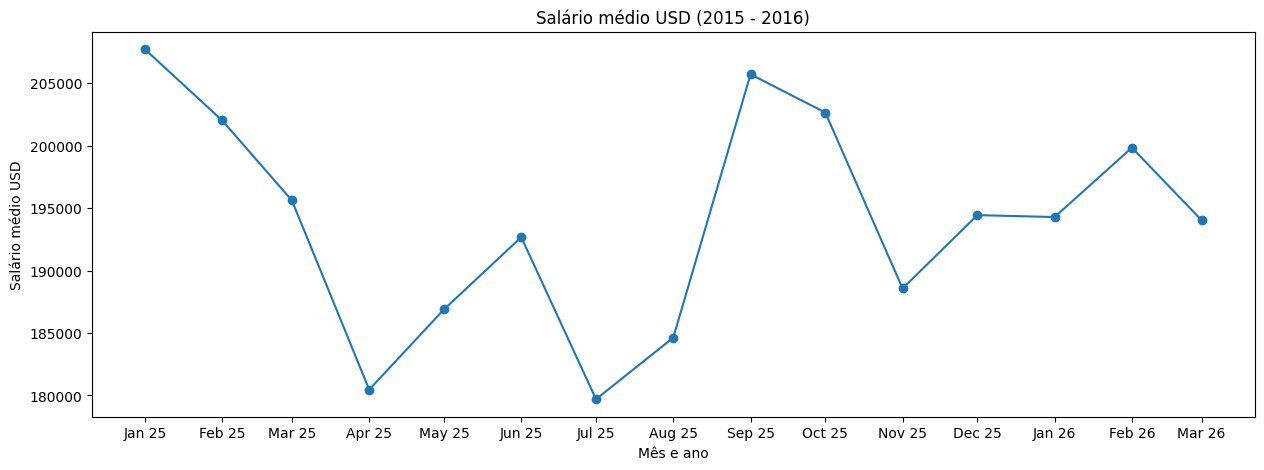

In [31]:
fig, ax = plt.subplots(figsize = (15,5))
df_dates = df_copy.groupby('posting_date').mean(numeric_only=True).reset_index()
df_dates['date_label'] = df_dates['posting_date'].apply(lambda x: datetime.strftime(x, "%b %y"))
ax.plot(df_dates['posting_date'], df_dates['annual_salary_usd'], marker='o')
ax.set_xticks(ticks=df_dates['posting_date'], labels=df_dates['date_label'])
ax.set_xlabel('Mês e ano')
ax.set_ylabel('Salário médio USD')
ax.set_title('Salário médio USD (2015 - 2016)')

# Respondendo as hipóteses

## Hipótese 1:
Ao longo do tempo existe uma tendência para uma maior proporção de anúncios de cargos de LLM?

In [32]:
aux_df = df_copy.groupby(['posting_date', 'is_llm_role']).size()
# aux_df possui um MultiIndex no formato (posting_date, is_llm_role)
# trazendo como valor o número de ocorrências de cada combinação de index.
aux_table = {'Posting Date': [], 'llm role %': []}
for index in aux_df.index.to_list():
    if index[0] in aux_table['Posting Date']:  # A data é repetida para o index is_llm_role 0 e 1
        continue
    sr = aux_df.loc[index[0]]
    aux_table['Posting Date'].append(index[0])
    # sr é o retorno do .loc em um posting date -> sr.loc[0] retorna o valor de is_llm_role = 0.
    aux_table['llm role %'].append(100 * sr.loc[1] / (sr.loc[0] + sr.loc[1]))
df_hp1 = pd.DataFrame(aux_table)
df_hp1['Date Label'] = df_hp1['Posting Date'].apply(lambda x: datetime.strftime(x, "%b %y"))
df_hp1.head(5)

,Posting Date,llm role %,Date Label
0,2025-01-01,24.390244,Jan 25
1,2025-02-01,18.181818,Feb 25
2,2025-03-01,25.000000,Mar 25
3,2025-04-01,34.146341,Apr 25
4,2025-05-01,15.625000,May 25


Text(0.5, 0, 'Mês e ano')

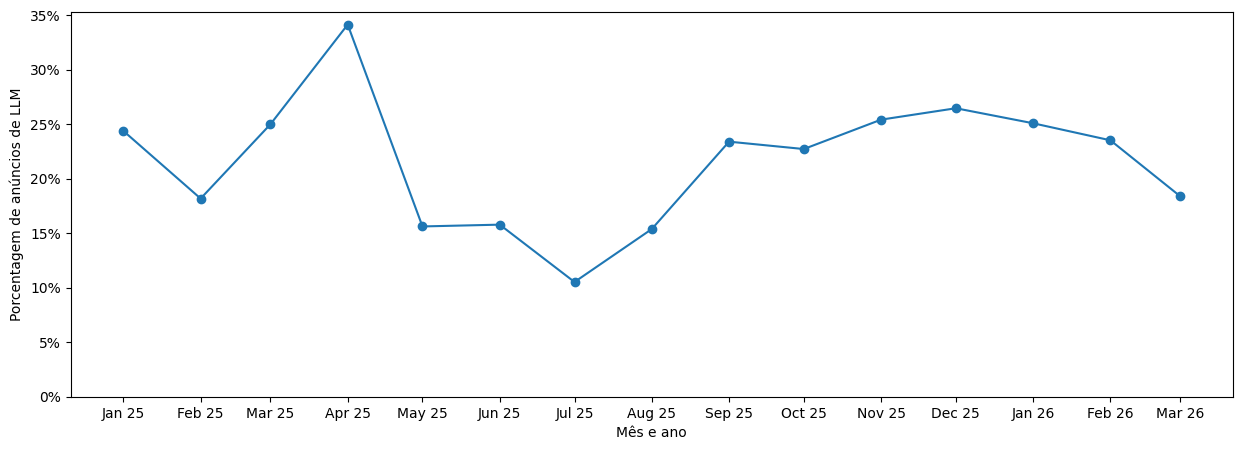

In [33]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(df_hp1['Posting Date'], df_hp1['llm role %'], marker='o')
ax.set_xticks(ticks=df_hp1['Posting Date'], labels=df_hp1['Date Label'])
yticks = range(0, 40, 5)
ax.set_yticks(ticks = yticks, labels = ["{:.0f}%".format(y) for y in yticks])
ax.set_ylabel('Porcentagem de anúncios de LLM')
ax.set_xlabel('Mês e ano')

In [34]:
df_hp1.describe()

,Posting Date,llm role %
count,15,15.000000
mean,2025-08-01 04:48:00,21.605731
min,2025-01-01 00:00:00,10.526316
25%,2025-04-16 00:00:00,16.985646
50%,2025-08-01 00:00:00,23.404255
75%,2025-11-16 00:00:00,25.046125
max,2026-03-01 00:00:00,34.146341
std,NaN,5.905338


## Análise Hipótese 1:

O gráfico de linha mostra a porcentagem de anúncios de LLM pelo mês/ano em que o anúncio foi feito.

Em abril de 2025 houve um pico de vagas de LLM no mercado, que logo no mês seguinte teve uma queda repentina, recuperando em setembro de 2025 proporções observadas em janeiro de 2025. Nos dados coletados (2025 e 2026) não é possível identificar uma tendência de crescimento na proporção de vagas de LLM ofertadas.

A média de porcentagem de anúncios de LLM é de 21,61 %, com um desvio padrão de 5,9 que pode ter sido influenciado pelo pico (abril de 2025) e vale (julho de 2025).

## Hipótese 2:

Número de anos de experiência exigido corresponde com o nível de experiência exigida (Entry, Mid, Senior, Lead)?

<Axes: xlabel='experience_level', ylabel='years_of_experience'>

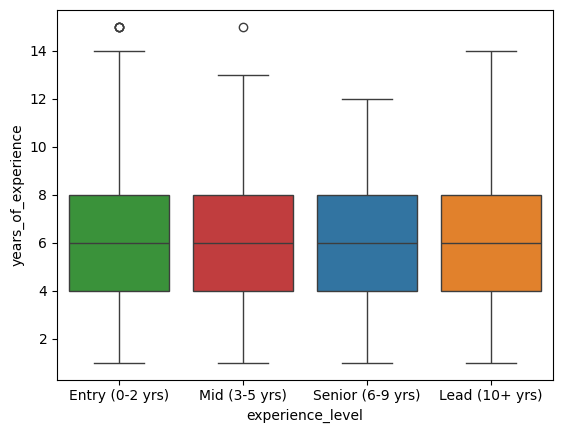

In [35]:
order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
sns.boxplot(x=df_copy['experience_level'], hue=df_copy['experience_level'], y=df_copy['years_of_experience'], order=order)

## Análise Hipóitese 2:

O boxplot mostra que os anos de experiência exigido nos anúncios não possuem correlação com a senioridade exigida. Inclusive, existem anúncios Entry e Mid que exigem anos de experiência superiores aos valores máximos encontrados para Senior e Lead. Existe a possibilidade de considerar que existem dados incorretos na feature years_of_experience, ou pode ser que há um erro no metadados de years_of_experience e que, na verdade, essa feature indique os anos de experiência do profissional que assumiu a vaga (alguns valores do dataset são publicações do profissional).

Caso a inferência anterior esteja correta, talvez explique cargos de Entry Level com altíssimo número de anos de experiência. Talvez seja um profissional que não conseguiu vagas de nível maior ou um profissional tentando reinserção no mercado.

Resposta: Número de anos de experiência ***não*** corresponde com o nível de senioridade exigido.

## Hipótese 3:

A habilidade mais requisitada nos anúncios é Python?

Text(0, 0.5, 'Habilidade')

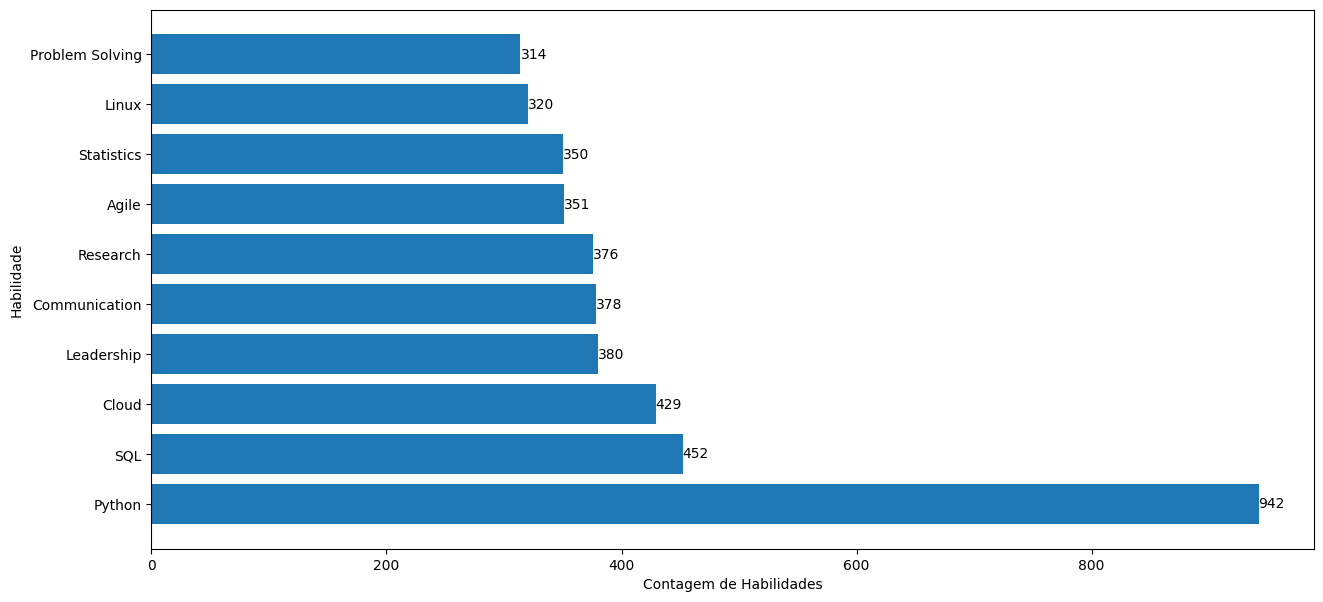

In [36]:
# As habilidades são separadas por | (pipes) em cada linha do dataset.
# Todos registros de habilidades são únicos. Será realizado um agrupamento de cada habilidade.

skills: list[int] = []
for i in range(df_copy.shape[0]):
    sr = df_copy.iloc[i]
    skills.extend(sr['required_skills'].split('|'))
df_h3 = pd.DataFrame(pd.Series(range(len(skills)), index=skills).groupby(level=0).count(), columns=['Contagem de Habilidades'])
df_h3 = df_h3.sort_values('Contagem de Habilidades', ascending=False).reset_index()
df_h3 = df_h3.rename(columns={'index': 'Skill'})
df_h3_head = df_h3.head(10)
fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(y=df_h3_head['Skill'], width=df_h3_head['Contagem de Habilidades'])
ax.bar_label(ax.containers[0], fmt="%.0f")
ax.set_xlabel('Contagem de Habilidades')
ax.set_ylabel('Habilidade')

## Análise Hipótese 3:

O gráfico de barras horizontais mostra que a habilidade que aparece mais vezes no dataset é Python, com 942 ocorrências, seguido de SQL e Cloud. É interessante perceber que as três habilidades mais comuns são técnicas e ligadas diretamente com a área de Ciências de Dados e ML, porém, a quarta e quinta habilidade mais requisitada estão ligadas a relações interpessoais, o que mostra que as vagas buscam profissionais técnicos, mas que consigam lidar bem com equipes.

Resposta: Sim. A habilidade mais requisitada na área de ML e IA é Python.

## Hipótese 4:

Existem situações em que o salário anual de anúncio Entry Level é maior do que níveis Senior ou Lead?

In [37]:
def apply_feature(sr: pd.Series, df: pd.DataFrame, new_features: list[str], targets: list[str]) -> None:
    salary = sr['annual_salary_usd']
    df = df.loc[df['annual_salary_usd'] < salary]
    for i in range(df.shape[0]):
        record = df.iloc[i]
        for target in targets:
            entry_target = sr[target]
            senior_target = record[target]
            if entry_target == senior_target:
                continue
            new_feature = f"({target}) - {entry_target} | {senior_target}"
            new_features.append(new_feature)

Text(0.5, 1.0, 'Motivos comuns para vaga Entry possuir salário maior que Senior/Lead')

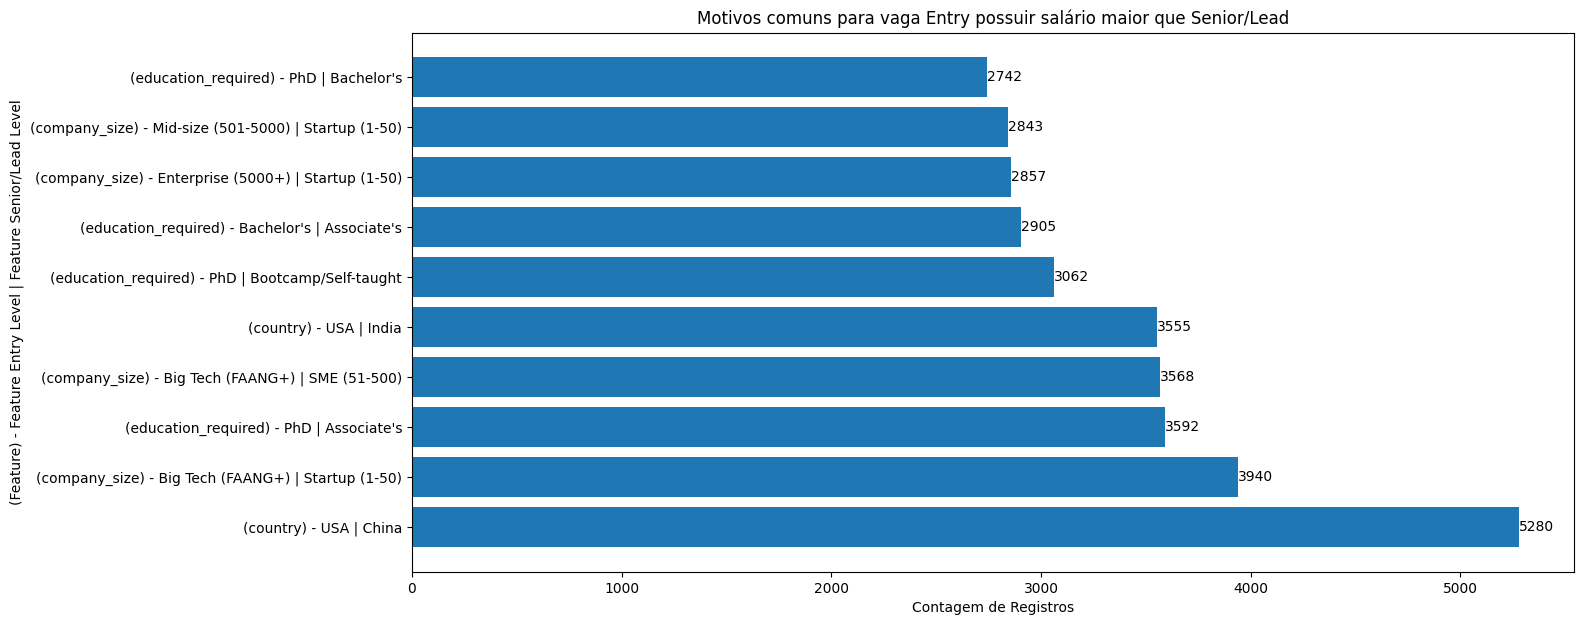

In [38]:
# Será coletado dados dos atributos (job_title, education_required, country, company_size, industry), de anúncios Entry que possuam annual_salary_usd maior que anúncios senior/lead.
# A ideia é tentar descobrir qual atributo (dos selecionados) possui maior peso na diferença entre salários.
# Será armazenado no formato "(Feature) - target_entry | target_senior_lead"
targets = ['job_title', 'education_required', 'country', 'company_size', 'industry']
df_h4 = df_copy[targets + ['experience_level', 'annual_salary_usd']]
df_entry = df_h4.loc[df_h4['experience_level'] == 'Entry (0-2 yrs)']
df_senior_lead = df_h4.loc[(level in ('Senior (6-9 yrs)', 'Lead (10+ yrs)') for level in df_h4['experience_level'])]
new_features: list[str] = []
df_entry.apply(apply_feature, args=(df_senior_lead, new_features, targets), axis=1)
sr_h4 = pd.Series(new_features)
sr_h4 = sr_h4.value_counts().head(10)

fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(y=sr_h4.index, width=sr_h4.values)
ax.bar_label(ax.containers[0], fmt="%.0f")
ax.set_xlabel('Contagem de Registros')
ax.set_ylabel('(Feature) - Feature Entry Level | Feature Senior/Lead Level')
ax.set_title('Motivos comuns para vaga Entry possuir salário maior que Senior/Lead')

## Análise Hipótese 4:

Vários insights interessantes que corroboram com análises dos atributos categóricos feitos nesse trabalho.

A situação mais comum em que uma vaga Entry possui salário maior que Senior/Lead é a localização da vaga. A China paga, em média, salários bem inferiores aos EUA.

A segunda situação mais comum é o tamanho da empresa do anúncio, com 3940 registros em que um anúncio Entry level em Big Tech possui salário superior que Senior/Lead em Startups.

Em seguida, o nível de escolaridade também gera um impacto, em que exigência de PhD em vagas Entry supera cargos Senior/Lead.

Resposta: Sim, existem diversas situações em que um anúncio Entry level supera o salário de anúncios Senior/Lead.

## Hipótese 5:

Existem países do globo em que anúncios voltados a LLM são mais comuns?

In [39]:
# A ideia é avaliar os países que possuem maior proporção de vagas de LLM.
# Como is_llm_role é binário (0 ou 1), a soma dos valores no groupby retorna os registros que a vaga é de LLM
# O count de country retorna o número total de registros.

agg_func = {
    'country': 'count',
    'is_llm_role': 'sum'
}

df_h5 = df_copy[['country', 'is_llm_role']].groupby('country').agg(agg_func)
df_h5.rename(columns={'country': 'Total de Anúncios', 'is_llm_role': 'Anúncio de LLM'}, inplace=True)
df_h5['Porcentagem de LLM'] = df_h5.apply(lambda x: 100 * x['Anúncio de LLM'] / x['Total de Anúncios'], axis=1)
df_h5.sort_values(by='Porcentagem de LLM', ascending=False, inplace=True)
df_h5

,Total de Anúncios,Anúncio de LLM,Porcentagem de LLM
country,,,
Singapore,71,23,32.394366
Global,82,22,26.829268
UK,90,24,26.666667
UAE,62,16,25.806452
Netherlands,74,19,25.675676
China,87,22,25.287356
USA,515,110,21.359223
France,66,14,21.212121
Switzerland,76,16,21.052632


Text(0.5, 1.0, 'Países com maior proporção de anúncios de LLM')

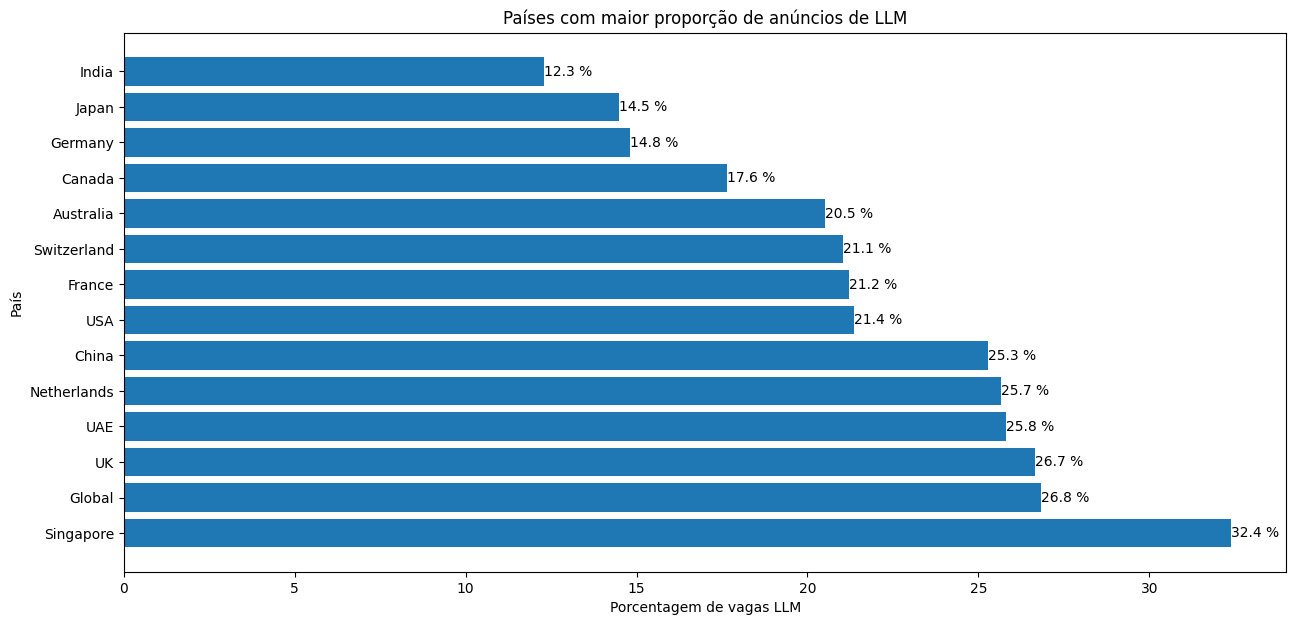

In [40]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.barh(y=df_h5.index, width=df_h5['Porcentagem de LLM'])
ax.bar_label(ax.containers[0], fmt="%.1f %%")
ax.set_xlabel('Porcentagem de vagas LLM')
ax.set_ylabel('País')
ax.set_title('Países com maior proporção de anúncios de LLM')

## Análise Hipótese 5:

A análise dessa hipótese trouxe resultados interessantes que não foram observados durante a análise dos atributos. Os EUA são o país com o maior número de anúncios de cargos voltados à LLM, conforme a tabela plotada, porém apenas 21,4 % das vagas anunciadas são de LLM. O país com maior proporção é Singapura, com 32,4 % das vagas anunciadas sendo de LLM. Interessante notar que existem países asiáticos (Índia e Japão) que possuem uma proporção muito inferior a de Singapura.

Resposta: Sim, é possível identificar qual país possui maior proporção de vagas voltadas a LLM.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Redução de dimensionalidade

A feature required_skills do dataset possui diversas habilidades separadas por "|" a cada linha do dataset, resultando que todas os registros dessa feature sejam únicos, ou seja, ao ser aplicado um encoding, resultaria em um número de colunas igual ao número de linhas do dataset, que pode não ser interessante para o modelo de ML.

Na análise da hipotése 3 foi criado um dataframe df_h3 com as habilidades mais comuns. A ideia é utilizar esse dataframe para simplificar a feature required_skills, tendo apenas o registro da habilidade mais comum solicitada na vaga.

Ex.: **APIs|Planning Systems|Python|Cloud|SQL|Leadership** será transformado em **Python**.

Assim, quando for aplicado o encoding, o número de dimensões será inferior e o modelo resultante será mais eficiente.

**Ponto de atenção**: Fazer essa transformação antes de separar o dataset em treino e teste incorre em risco de data leakage. Para o contexto desse MVP essa transformação específica não é um problema. Os encodings, padronização e normalização serão realizados no dataset dividido.

In [41]:
def get_common_skill(skills: str, skill_list: list[str]) -> str:
    skills = skills.split("|")
    for skill in skill_list:
        if skill in skills:
            return skill

In [42]:
df_copy['required_skills'] = df_copy['required_skills'].apply(get_common_skill, args=(df_h3['Skill'].values,))
df_copy['required_skills'].unique()

array(['Python', 'Cloud', 'Communication', 'Research', 'SQL', 'Agile',
       'Leadership', 'Statistics', 'Git', 'Linux', 'Problem Solving',
       'PyTorch'], dtype=object)

A feature required_skills passou a ter 12 valores únicos. Antes da redução essa feature possuia 1500 valores únicos.

### Análise do atributo Required Skill

Com o tratamento dos dados da coluna required_skills, se tornou prático a visualização do salário médio anual para cada habilidade, conforme realizado com os outros atributos categóricos do dataset.

A habilidade associada com maior salário médio anual é PyTorch, ferramenta utilizada para criação de modelos de deep learning. Python, habilidade que aparece com maior frequência, está na sexta posição do ranking.

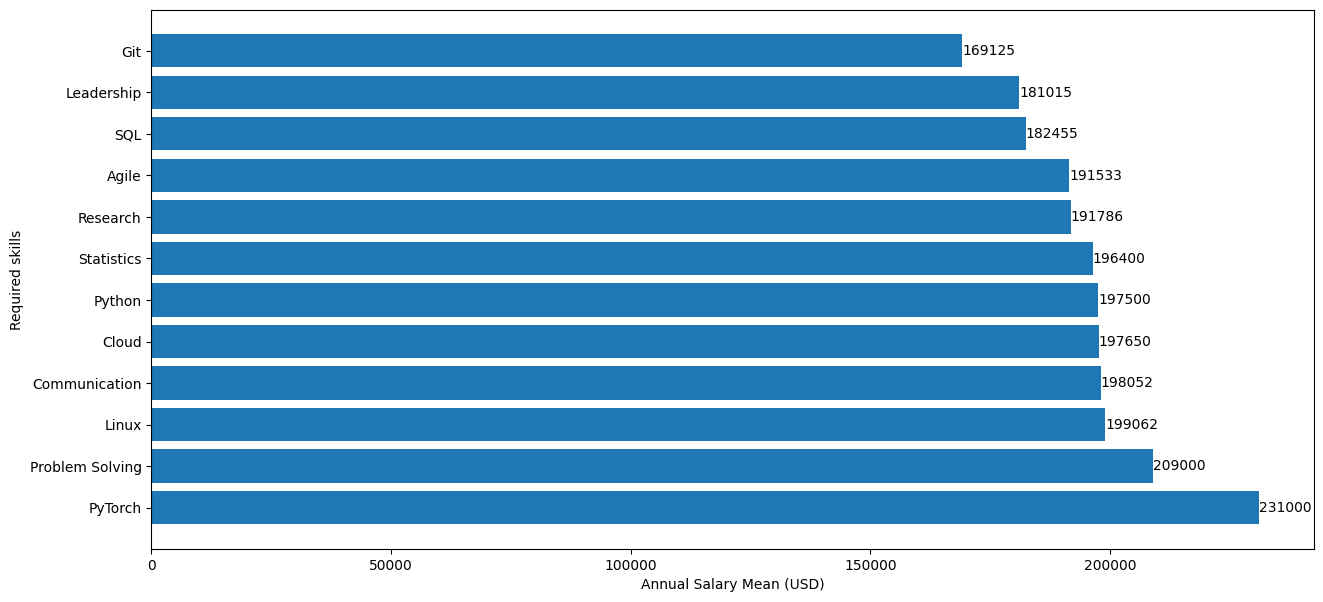

In [43]:
categoric_feature_bar_plot(df_copy, 'required_skills')

## Divisão do dataset em conjuntos de treino e teste

Essa etapa é essencial para o treinamento supervisionado do modelo. Além disso, essa etapa precisa ser realizada antes de realizar transformações no dataset que utilizam informações sobre o dataset para evitar o data leakage.

**Ponto de atenção**: Para esse trabalho, será descartada a coluna posting_date de tipo datetime, por não estar no escopo atual da sprint a implementação de modelos de ML mais complexos.

In [44]:
df_copy.drop(columns=['posting_date'], inplace=True)
# Separar features (X) e target (y)
X = df_copy.drop('annual_salary_usd', axis=1)
y = df_copy['annual_salary_usd']

In [45]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [46]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (1050, 16)
Dimensões de X_test: (450, 16)
Dimensões de y_train: (1050,)
Dimensões de y_test: (450,)


In [47]:
# Resetando o index para poder utilizar pd.concat() na fase de onehot encoding.
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

## Encoding de features categóricas

Para a criação do modelo é necessário transformar as variáveis categóricas em variáveis numéricas.

Para variáveis categóricas que possuem ordenação, será utilizado o Ordinal Encoding, para manter o significado de que uma variável tem um peso maior do que outra. As features que precisarão do Ordinal Enconding são:
- experience_level
- education_required
- company_size

Para as outras variáveis categóricas, será utilizado o dummy encoding.

### Ordinal Encoding

As variáveis ordinais foram listadas na variável categories: list[list[str]], com a list na ith posição sendo igual a posição da feature no dataframe passado para o encoder.

Foram utilizadas apenas as variáveis presentes em X_train para definir a ordem das categorias para evitar data leakage.

Comparando o print de X_train.head() antes e depois da transformação é possível verificar que o Ordinal Encoding foi efetuado com sucesso, com o valor associado à variável seguindo a lógica de ordem estabelecida.

In [48]:
print(f'experience_level: {list(X_train["experience_level"].unique())}')
print(f'education_required: {list(X_train["education_required"].unique())}')
print(f'company_size: {list(X_train["company_size"].unique())}')

experience_level: ['Entry (0-2 yrs)', 'Senior (6-9 yrs)', 'Mid (3-5 yrs)', 'Lead (10+ yrs)']
education_required: ["Master's", "Bachelor's", 'PhD', 'Bootcamp/Self-taught', "Associate's"]
company_size: ['Enterprise (5000+)', 'Big Tech (FAANG+)', 'SME (51-500)', 'Mid-size (501-5000)', 'Startup (1-50)']


In [49]:
# Antes do encoding
X_train.head()

,job_title,job_category,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role
0,AI Product Manager,Product,Entry (0-2 yrs),6,Master's,Singapore,Singapore,Fully Remote,Enterprise (5000+),Media,Leadership,10.2,85,14.1,9.4,0
1,MLOps Engineer,ML Operations,Senior (6-9 yrs),9,Bachelor's,New York,USA,Fully Remote,Big Tech (FAANG+),Government,Python,17.3,93,69.9,9.1,0
2,Robotics Engineer (AI),Robotics,Entry (0-2 yrs),5,PhD,Boston,USA,Hybrid,SME (51-500),Technology,SQL,13.4,76,30.0,7.8,0
3,Deep Learning Engineer,AI Engineering,Senior (6-9 yrs),8,Bootcamp/Self-taught,Chicago,USA,On-site,Mid-size (501-5000),Research,Python,3.9,89,19.9,6.2,0
4,AI Agent Developer,AI Engineering,Entry (0-2 yrs),7,Associate's,New York,USA,On-site,Mid-size (501-5000),Government,Python,17.0,96,61.9,6.7,1


In [50]:
categories = [
    ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)'],
    ['Bootcamp/Self-taught', "Associate's", "Bachelor's", "Master's", 'PhD'],
    ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']
]
values = X_train[['experience_level', 'education_required', 'company_size']]
enc_ordinal = OrdinalEncoder(categories=categories)
enc_ordinal.fit(values)
X_train[['experience_level', 'education_required', 'company_size']] = enc_ordinal.transform(values)

In [51]:
#Após encoding
X_train.head(5)

,job_title,job_category,experience_level,years_of_experience,education_required,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role
0,AI Product Manager,Product,0.0,6,3.0,Singapore,Singapore,Fully Remote,3.0,Media,Leadership,10.2,85,14.1,9.4,0
1,MLOps Engineer,ML Operations,2.0,9,2.0,New York,USA,Fully Remote,4.0,Government,Python,17.3,93,69.9,9.1,0
2,Robotics Engineer (AI),Robotics,0.0,5,4.0,Boston,USA,Hybrid,1.0,Technology,SQL,13.4,76,30.0,7.8,0
3,Deep Learning Engineer,AI Engineering,2.0,8,0.0,Chicago,USA,On-site,2.0,Research,Python,3.9,89,19.9,6.2,0
4,AI Agent Developer,AI Engineering,0.0,7,1.0,New York,USA,On-site,2.0,Government,Python,17.0,96,61.9,6.7,1


### Dummy Encoding

A seguir o Dummy Encoding nas outras variáveis categóricas.

A ordem dos dados em encoded_data permaneceu igual ao dados de X_train, com isso em mente foi utilizado o pd.concat que utiliza o index dos dataframes para a concatenação. Por esse motivo foi chamado o método reset_index no dataframa X_train e X_test após a divisão em treino e teste.

O novo dataframe possui shape (1050, 101). O print de X_train.head(5) mostra exemplos que o encoding ocorreu com sucesso.

In [52]:
enc_dummy = OneHotEncoder(drop='first', sparse_output=False)
to_encode = ['job_title', 'job_category', 'city', 'country', 'remote_work', 'industry', 'required_skills']
enc_dummy.fit(X_train[to_encode])
encoded_data = enc_dummy.transform(X_train[to_encode])
X_train.drop(columns=to_encode, inplace=True)
df_dummy = pd.DataFrame(encoded_data, columns=enc_dummy.get_feature_names_out())
X_train = pd.concat([X_train, df_dummy], axis=1)
print(X_train.shape)
X_train.head(5)

(1050, 100)


,experience_level,years_of_experience,education_required,company_size,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,is_llm_role,job_title_AI Business Analyst,...,required_skills_Communication,required_skills_Git,required_skills_Leadership,required_skills_Linux,required_skills_Problem Solving,required_skills_PyTorch,required_skills_Python,required_skills_Research,required_skills_SQL,required_skills_Statistics
0,0.0,6,3.0,3.0,10.2,85,14.1,9.4,0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,9,2.0,4.0,17.3,93,69.9,9.1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,5,4.0,1.0,13.4,76,30.0,7.8,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.0,8,0.0,2.0,3.9,89,19.9,6.2,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,7,1.0,2.0,17.0,96,61.9,6.7,1,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Padronização e Normalização

A Padronização transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais. A padronização não é interessante quando o dataset possui features com distribuição não normal, como é o caso do dataset trabalhado.

A Normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante. Essa escala possui desvantagem quando a distribuição das features do dataset não são uniformes, comportamento encontrado no dataset trabalhado. Além disso, essa escala é particularmente ruim quando existem dados com distribuição assimétrica, pois os valores nos extremos tendem a serem mais comprimidos.

Como as duas escalas possuem desvantagem semelhante, será escolhido inicialmente trabalhar com a Padronização, pois além de normalizar o dataset, pode ser vantajoso possuir uma média nula e desvio padrão próximo a 1 para alguns modelos de ML.

Para trabalhos futuros com escopo em modelos de ML, será realizado testes para identificar qual técnica é a mais eficiente para o dataset trabalhado.

In [53]:
standard_scaler = StandardScaler()
standard_scaler.fit(X_train)
standard_data = standard_scaler.transform(X_train)
pd.DataFrame(standard_data).describe()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
count,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,...,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03,1.050000e+03
mean,-1.353415e-17,-1.234991e-16,8.797196e-17,-3.256654e-17,-4.060244e-17,-7.760988e-16,-1.590262e-16,3.214360e-16,-7.612958e-18,-3.383537e-17,...,6.767074e-18,-3.214360e-17,3.383537e-18,3.383537e-17,-2.706829e-17,-3.383537e-18,-6.090366e-17,-5.244482e-17,-5.413659e-17,4.736952e-17
std,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,...,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00,1.000477e+00
min,-1.322845e+00,-1.969018e+00,-1.406686e+00,-1.419994e+00,-1.954124e+00,-2.490912e+00,-1.190403e+00,-1.714466e+00,-5.310850e-01,-2.066424e-01,...,-2.091353e-01,-9.298136e-02,-2.091353e-01,-1.162476e-01,-9.298136e-02,-3.087538e-02,-1.308884e+00,-2.041241e-01,-3.208445e-01,-1.203859e-01
25%,-1.322845e+00,-8.225472e-01,-6.941824e-01,-7.089811e-01,-6.594368e-01,-4.679340e-01,-7.264043e-01,-8.917522e-01,-5.310850e-01,-2.066424e-01,...,-2.091353e-01,-9.298136e-02,-2.091353e-01,-1.162476e-01,-9.298136e-02,-3.087538e-02,-1.308884e+00,-2.041241e-01,-3.208445e-01,-1.203859e-01
50%,-4.261458e-01,-5.823343e-02,1.832153e-02,2.031465e-03,-8.678672e-02,2.906826e-01,-3.382516e-01,-6.903832e-02,-5.310850e-01,-2.066424e-01,...,-2.091353e-01,-9.298136e-02,-2.091353e-01,-1.162476e-01,-9.298136e-02,-3.087538e-02,7.640094e-01,-2.041241e-01,-3.208445e-01,-1.203859e-01
75%,4.705538e-01,7.060804e-01,7.308255e-01,7.130441e-01,8.095352e-01,9.228632e-01,5.317458e-01,8.450882e-01,-5.310850e-01,-2.066424e-01,...,-2.091353e-01,-9.298136e-02,-2.091353e-01,-1.162476e-01,-9.298136e-02,-3.087538e-02,7.640094e-01,-2.041241e-01,-3.208445e-01,-1.203859e-01
max,1.367253e+00,3.381179e+00,1.443329e+00,1.424057e+00,1.780551e+00,1.302172e+00,2.499278e+00,1.759215e+00,1.882938e+00,4.839277e+00,...,4.781593e+00,1.075484e+01,4.781593e+00,8.602325e+00,1.075484e+01,3.238827e+01,7.640094e-01,4.898979e+00,3.116775e+00,8.306624e+00


# Conclusão

A análise e pré-processamento de dados do dataset IA Jobs Market 2025 and 2026 é fundamental para a modelagem. A análise teve como resultado uma compreensão do conjunto de dados que tornou possível fazer a aplicação de técnicas de pré-processamento, como a escolha de como escalar os dados para alimentar o modelo; a noção de que alguns dos atributos categóricos do dataset são ordinais, necessitando a aplicação do Ordinal Encoding para que o modelo pudesse ter a informação do peso de cada caracteríscas; a informação de que a coluna required_skills precisaria de uma transformação para produzir dados significantes para produção do modelo.

A análise de dados mostrou correlações fracas entre as variáveis númericas com a variável target annual_salary_usd, porém foi possível observar através de gráficos que muitas features categóricas possuiam relação com o target, por exemplo, as colunas company_size e country possuem grande influência no valor de annual_salary_usd, chegando ao ponto de, como visto na resposta da hipótese 4, termos vagas Entry Level nos EUA com oferta de salário superior a vagas Senior/Lead na China.

Em trabalhos futuros, será considerado uma melhor utilização da coluna posting_date no treinamento do modelo utilizando feature engineering, um cuidado maior na transformação de dados que ocorreu na coluna required_skills para evitar data leakage e tentar outros algorítmos de normalização de dados, verificando qual o mais efetivo para criação do modelo.

As hipóteses levantadas foram analisadas:

1. **Ao longo do tempo existe uma tendência para uma maior proporção de anúncios de cargos de LLM?** Não é possível identificar uma tendência de crescimento na proporção de vagas de LLM ofertadas

2. **Número de anos de experiência exigido corresponde com o nível de experiência exigida (Entry, Mid, Senior, Lead)?** Não. O número de anos de experiência ***não*** corresponde com o nível de senioridade exigido.

3. **A habilidade mais requisitada nos anúncios é Python?** Sim. A habilidade mais requisitada na área de ML e IA é Python.

4. **Existem situações em que o salário anual de anúncio Entry Level é maior do que níveis Senior ou Lead?** Sim, existem diversas situações em que um anúncio Entry level supera o salário de anúncios Senior/Lead.

5. **Existem países do globo em que anúncios voltados a LLM são mais comuns?** Sim, é possível identificar qual país possui maior proporção de vagas voltadas a LLM.